# 04 — Workload & Stress Analysis (EDA)
Compare engagement and burnout risk across overtime status, travel frequency, and commute distance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/processed/full_scored.csv')
df.shape

(1470, 38)

## Overtime vs non-overtime employees

In [2]:
df.groupby('OverTime')[['EngagementIndex']].mean()

,EngagementIndex
OverTime,
No,0.526910
Yes,0.557911


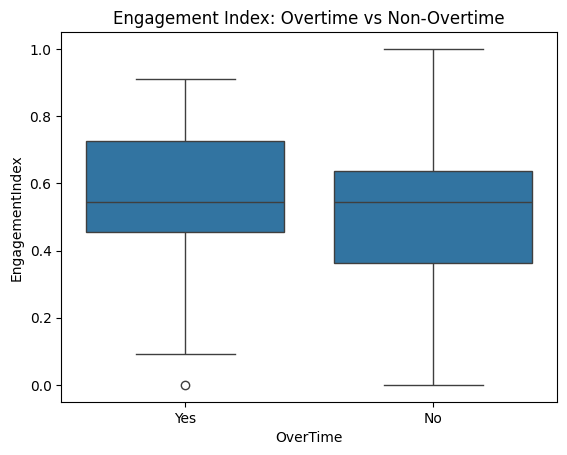

In [3]:
sns.boxplot(data=df, x='OverTime', y='EngagementIndex')
plt.title('Engagement Index: Overtime vs Non-Overtime')
plt.show()

## Travel frequency categories

In [4]:
df.groupby('BusinessTravel')[['EngagementIndex']].mean().sort_values('EngagementIndex')

,EngagementIndex
BusinessTravel,
Travel_Rarely,0.532555
Non-Travel,0.540000
Travel_Frequently,0.545126


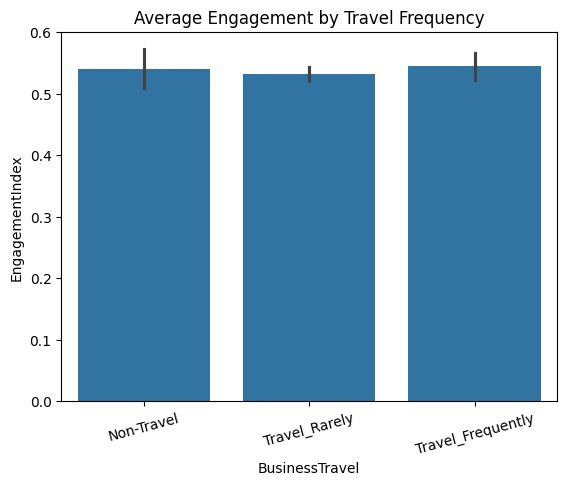

In [5]:
sns.barplot(data=df, x='BusinessTravel', y='EngagementIndex',
            order=['Non-Travel', 'Travel_Rarely', 'Travel_Frequently'])
plt.title('Average Engagement by Travel Frequency')
plt.xticks(rotation=15)
plt.show()

## Commute distance (long vs short)
Split `DistanceFromHome` at the median into 'short' and 'long' commute groups and compare engagement.

In [6]:
median_dist = df['DistanceFromHome'].median()
df['CommuteGroup'] = df['DistanceFromHome'].apply(
    lambda x: 'Long commute' if x > median_dist else 'Short commute')
df.groupby('CommuteGroup')[['EngagementIndex']].mean()

,EngagementIndex
CommuteGroup,
Long commute,0.535513
Short commute,0.535836


## Burnout risk share by overtime + travel

In [7]:
risk_by_group = pd.crosstab(
    [df['OverTime'], df['BusinessTravel']], df['BurnoutRisk'], normalize='index'
).round(2)
risk_by_group

BurnoutRisk                 High   Low  Medium
OverTime BusinessTravel                       
No       Non-Travel         0.02  0.11    0.87
         Travel_Frequently  0.03  0.10    0.87
         Travel_Rarely      0.04  0.09    0.87
Yes      Non-Travel         0.37  0.00    0.63
         Travel_Frequently  0.33  0.00    0.67
         Travel_Rarely      0.38  0.00    0.62

## Workload Stress Indicator
A simple combined indicator: proportion of high-travel + overtime employees who fall into High burnout risk.

In [8]:
stressed = df[(df['OverTime'] == 'Yes') & (df['BusinessTravel'] == 'Travel_Frequently')]
pct_high_risk = (stressed['BurnoutRisk'] == 'High').mean() * 100
print(f'{pct_high_risk:.1f}% of frequent-travel + overtime employees are High burnout risk')

32.6% of frequent-travel + overtime employees are High burnout risk
